# API
---

* Application Programming Interface
* Es una interfaz que permite que dos sistemas se comuniquen entre sí (aplicaciones web, servicios, backend-backend, etc.)

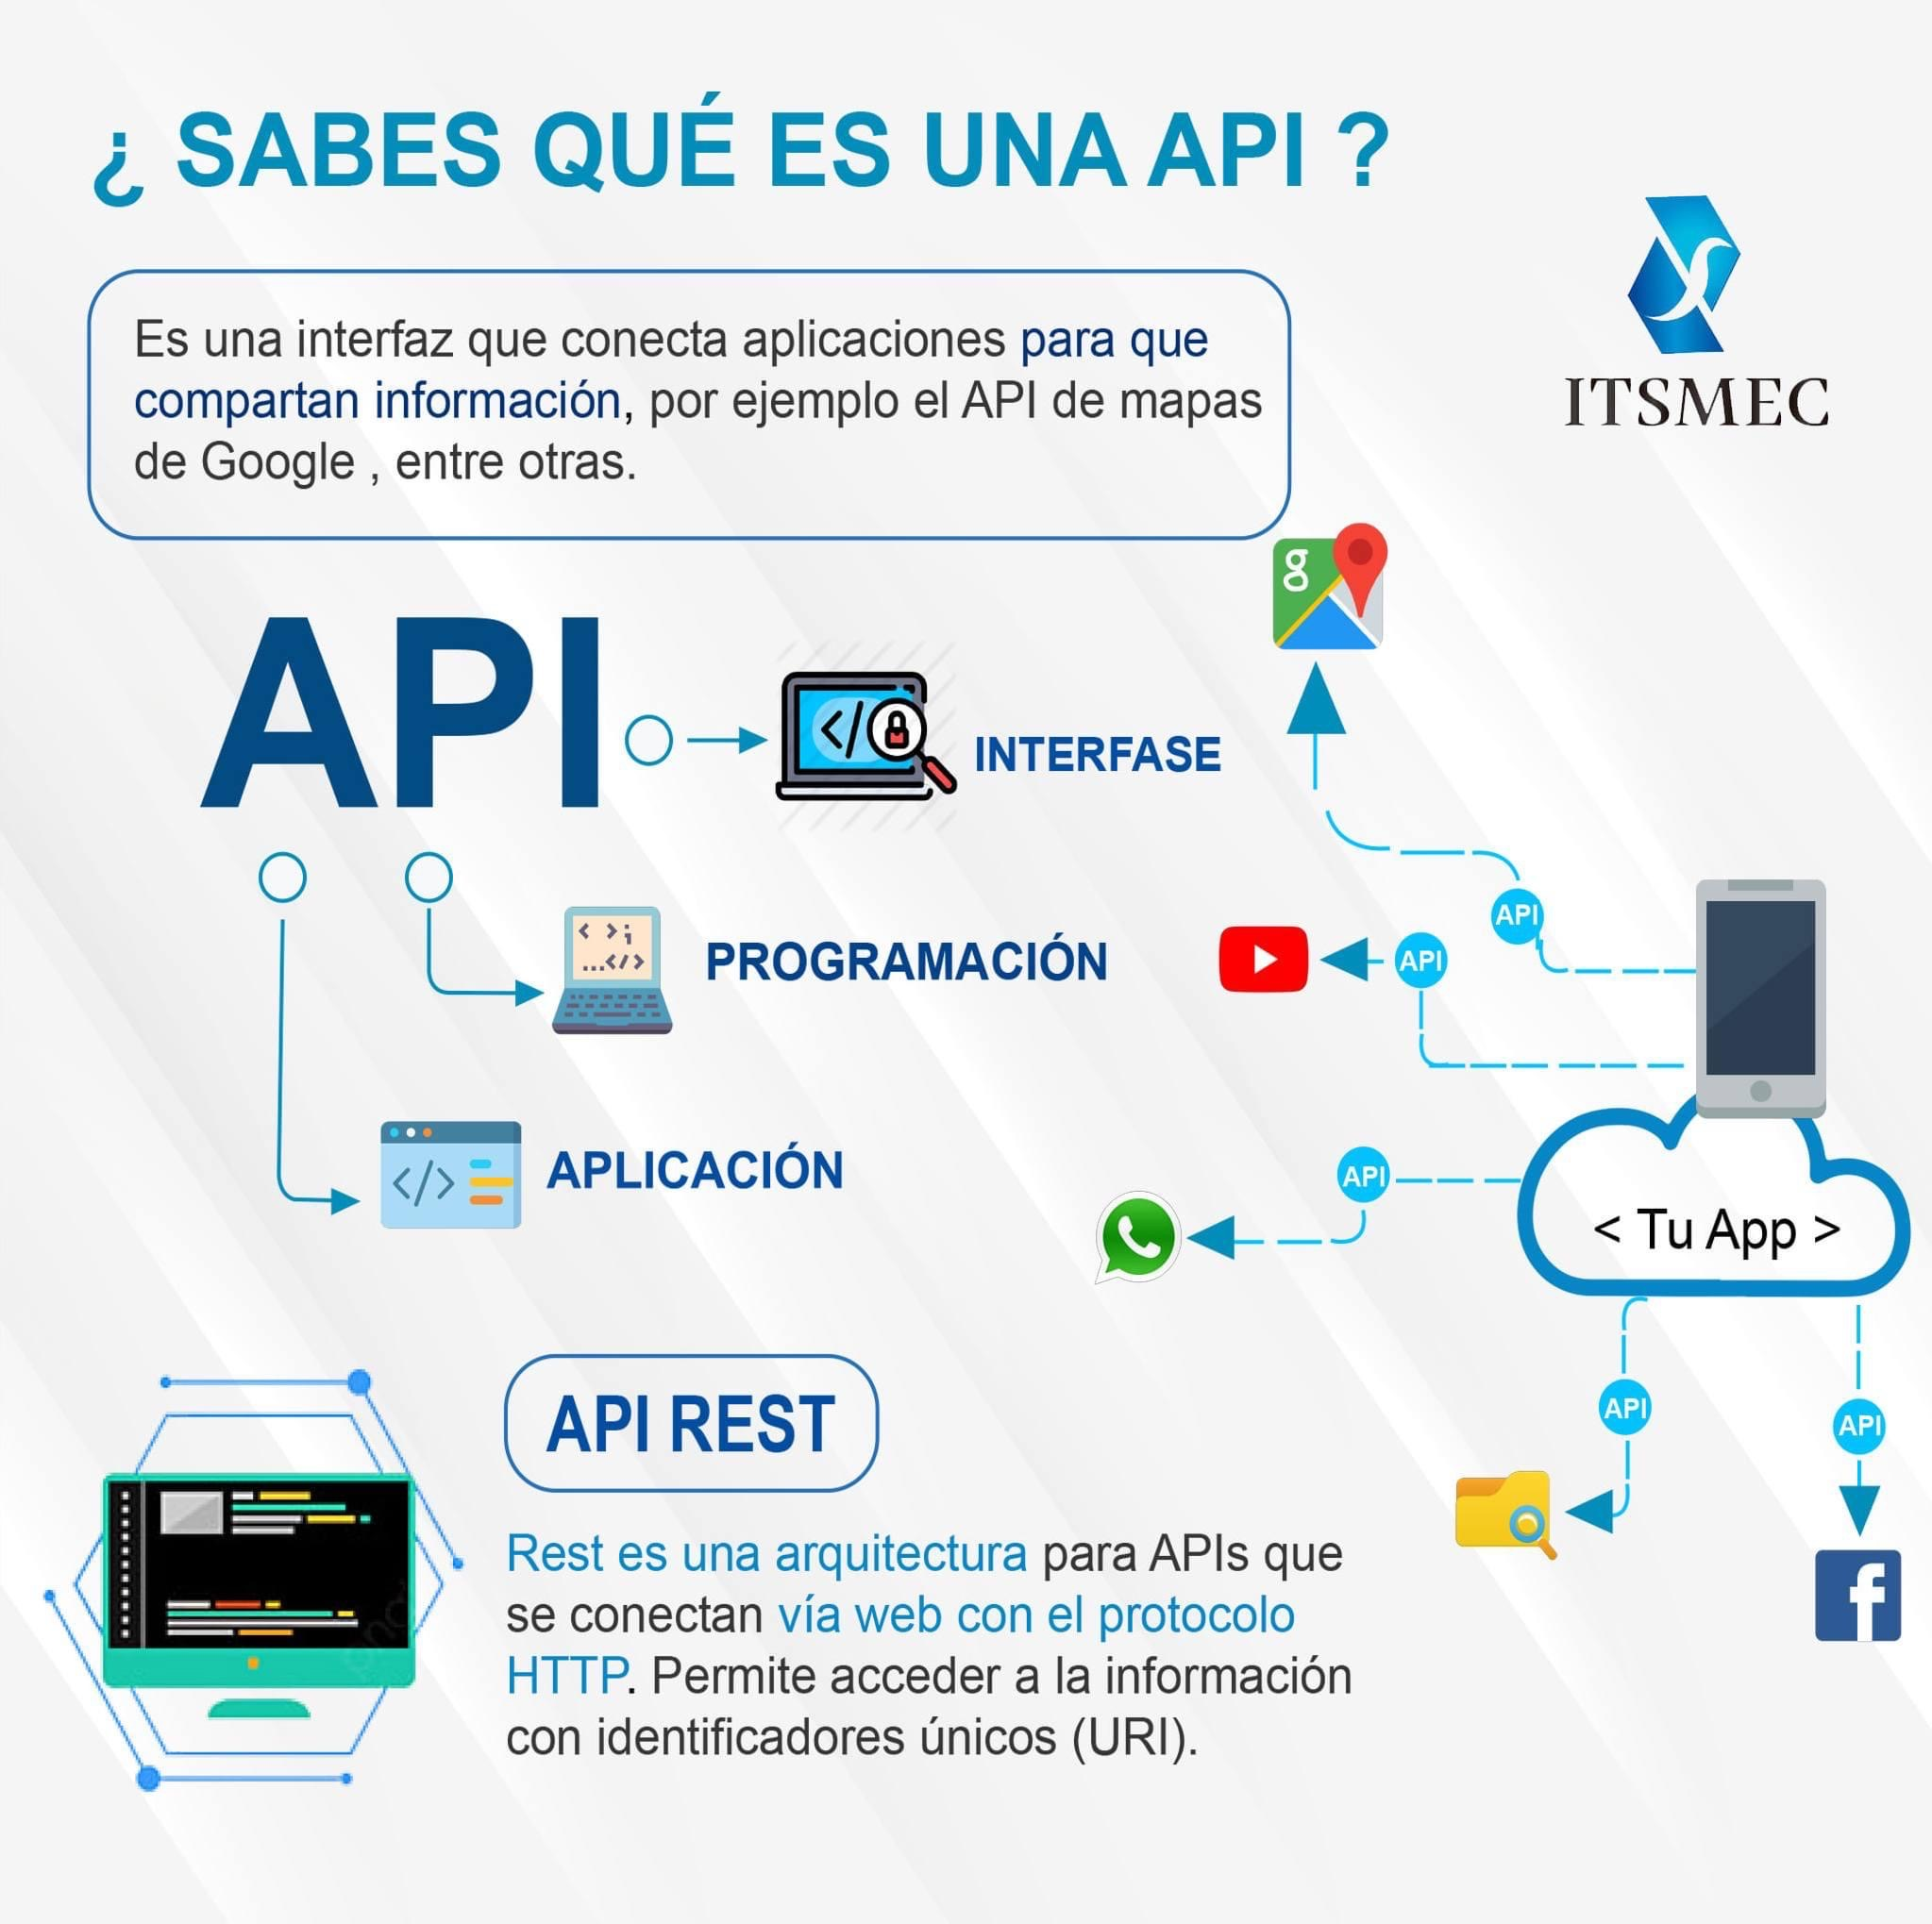

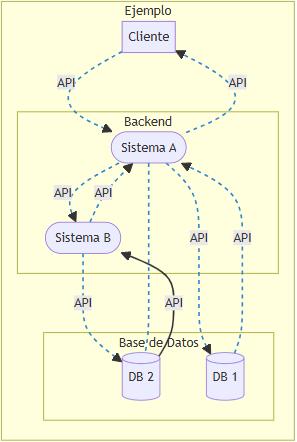

## Tipos de APIs

* Existen diferentes tipos de APIs dependiendo de las características que posean:
    * WebService (WS)
    * Conexiones a las Bases de Datos
    * Interacciones con el Sistema Operativo
    * Etc.

* Los WS tienen la característica de ser APIs que se usan vía internet
* Debido a ello, son los utilizados para interactuar con aplicaciones web
* Dentro de los WebService, los más comunes son los: 
    * SOAP
    * REST

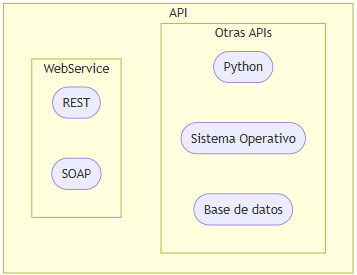

## Comparación entre API REST y API SOAP

| Característica	  | API REST	                                | API SOAP                                |
| --                  | --                                          | --                                      |
| Significado         | Representational State Transfer             | Simple Object Access Protocol           |
| Formato de datos	  | Generalmente JSON (también XML, YAML, etc.) | Exclusivamente XML                      |
| Operaciones típicas |	GET, POST, PUT, DELETE	                    | Métodos definidos por el servicio (RPC) |
| Ejemplo de llamada  |	GET https://api.ejemplo.com/usuarios/1	    | <soap:Envelope>...</soap:Envelope>      |

## Estructura de un WS-REST

* Endpoint: https://abm.arquitectura.dqs.afip.gob.ar/abm/api/agenda?id=1234
    * **Service**: https://abm.arquitectura.dqs.afip.gob.ar/abm/api
    * **Resource**: /agenda
    * **Parameters**: ?id=1234
    * **Method**: GET, POST, PUT, DELETE, etc
    * **Header**: autenticación, tipo de contenido (content_type)
    * **Body**: puede ser JSON o XML (los mas comunes)

## Métodos HTTP

| Verbo	 | Función	              | Ejemplo        |
| --     | --                     | --             |
| GET	 | Obtener datos	      | GET /agenda    |
| POST	 | Crear recurso	      | POST /agenda   |
| PUT	 | Reemplazar recurso     |	PUT /agenda    |
| PATCH	 | Modificar parcialmente |	PATCH /agenda  |
| DELETE | Eliminar recurso	      | DELETE /agenda |

## Estructura de un WS-SOAP

* Endpoint: https://abm.arquitectura.dqs.afip.gob.ar/abm/ws/AgendaService
    * **Servicio**: https://abm.arquitectura.dqs.afip.gob.ar/abm/ws
    * **Resource**: AgendaService
    * **Method**: POST
    * **Header**: Content-Type: text/xml
    * **Body**: el mensaje se envía en formato XML dentro de un envelope SOAP

## Status code

| Código | Significado  |
| --     | --           |
| 200    | OK           |
| 201	 | Created      |
| 400	 | Bad Request  |
| 401    | Unauthorized |
| 404    | Not Found    |
| 500    | Server Error |

## Request

* Es una librería Python.
* Facilita el trabajo con peticiones HTTP (acceso a internet):
    * consumir un API.
    * extraer información de una página.
    * enviar el contenido de un formulario de manera automatizada.

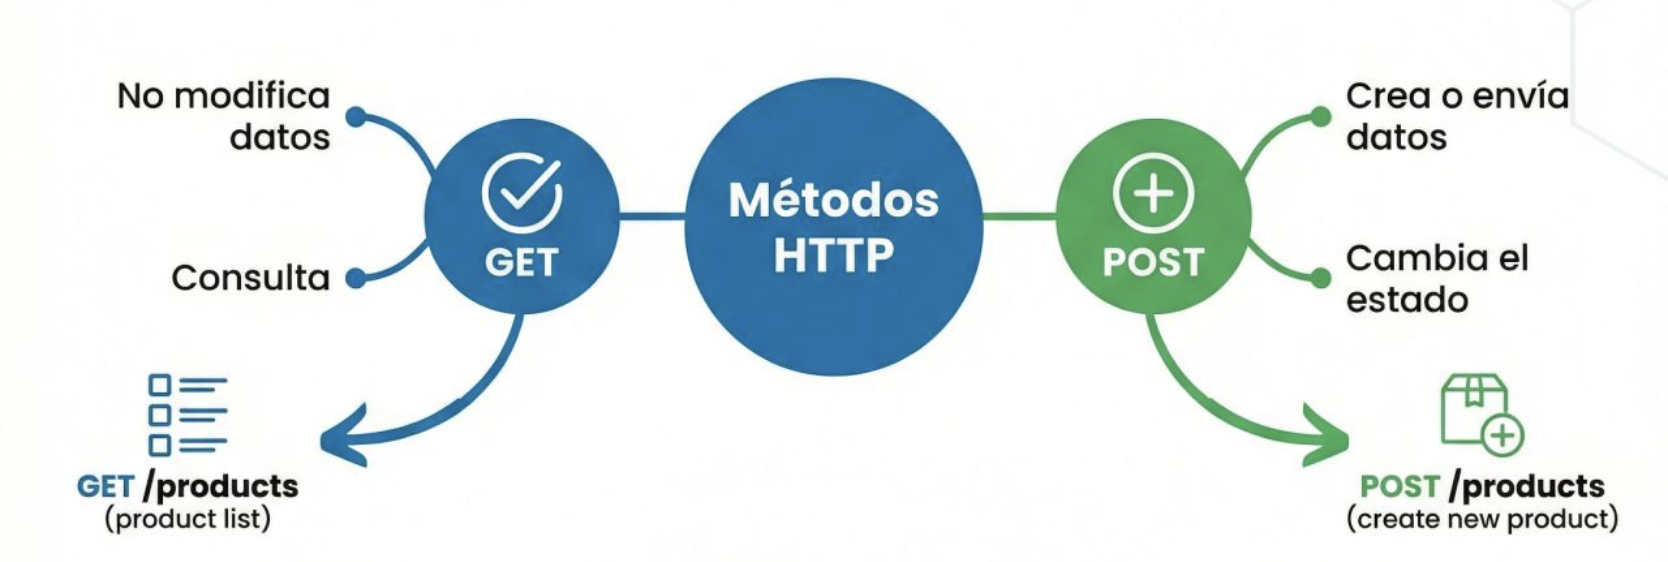

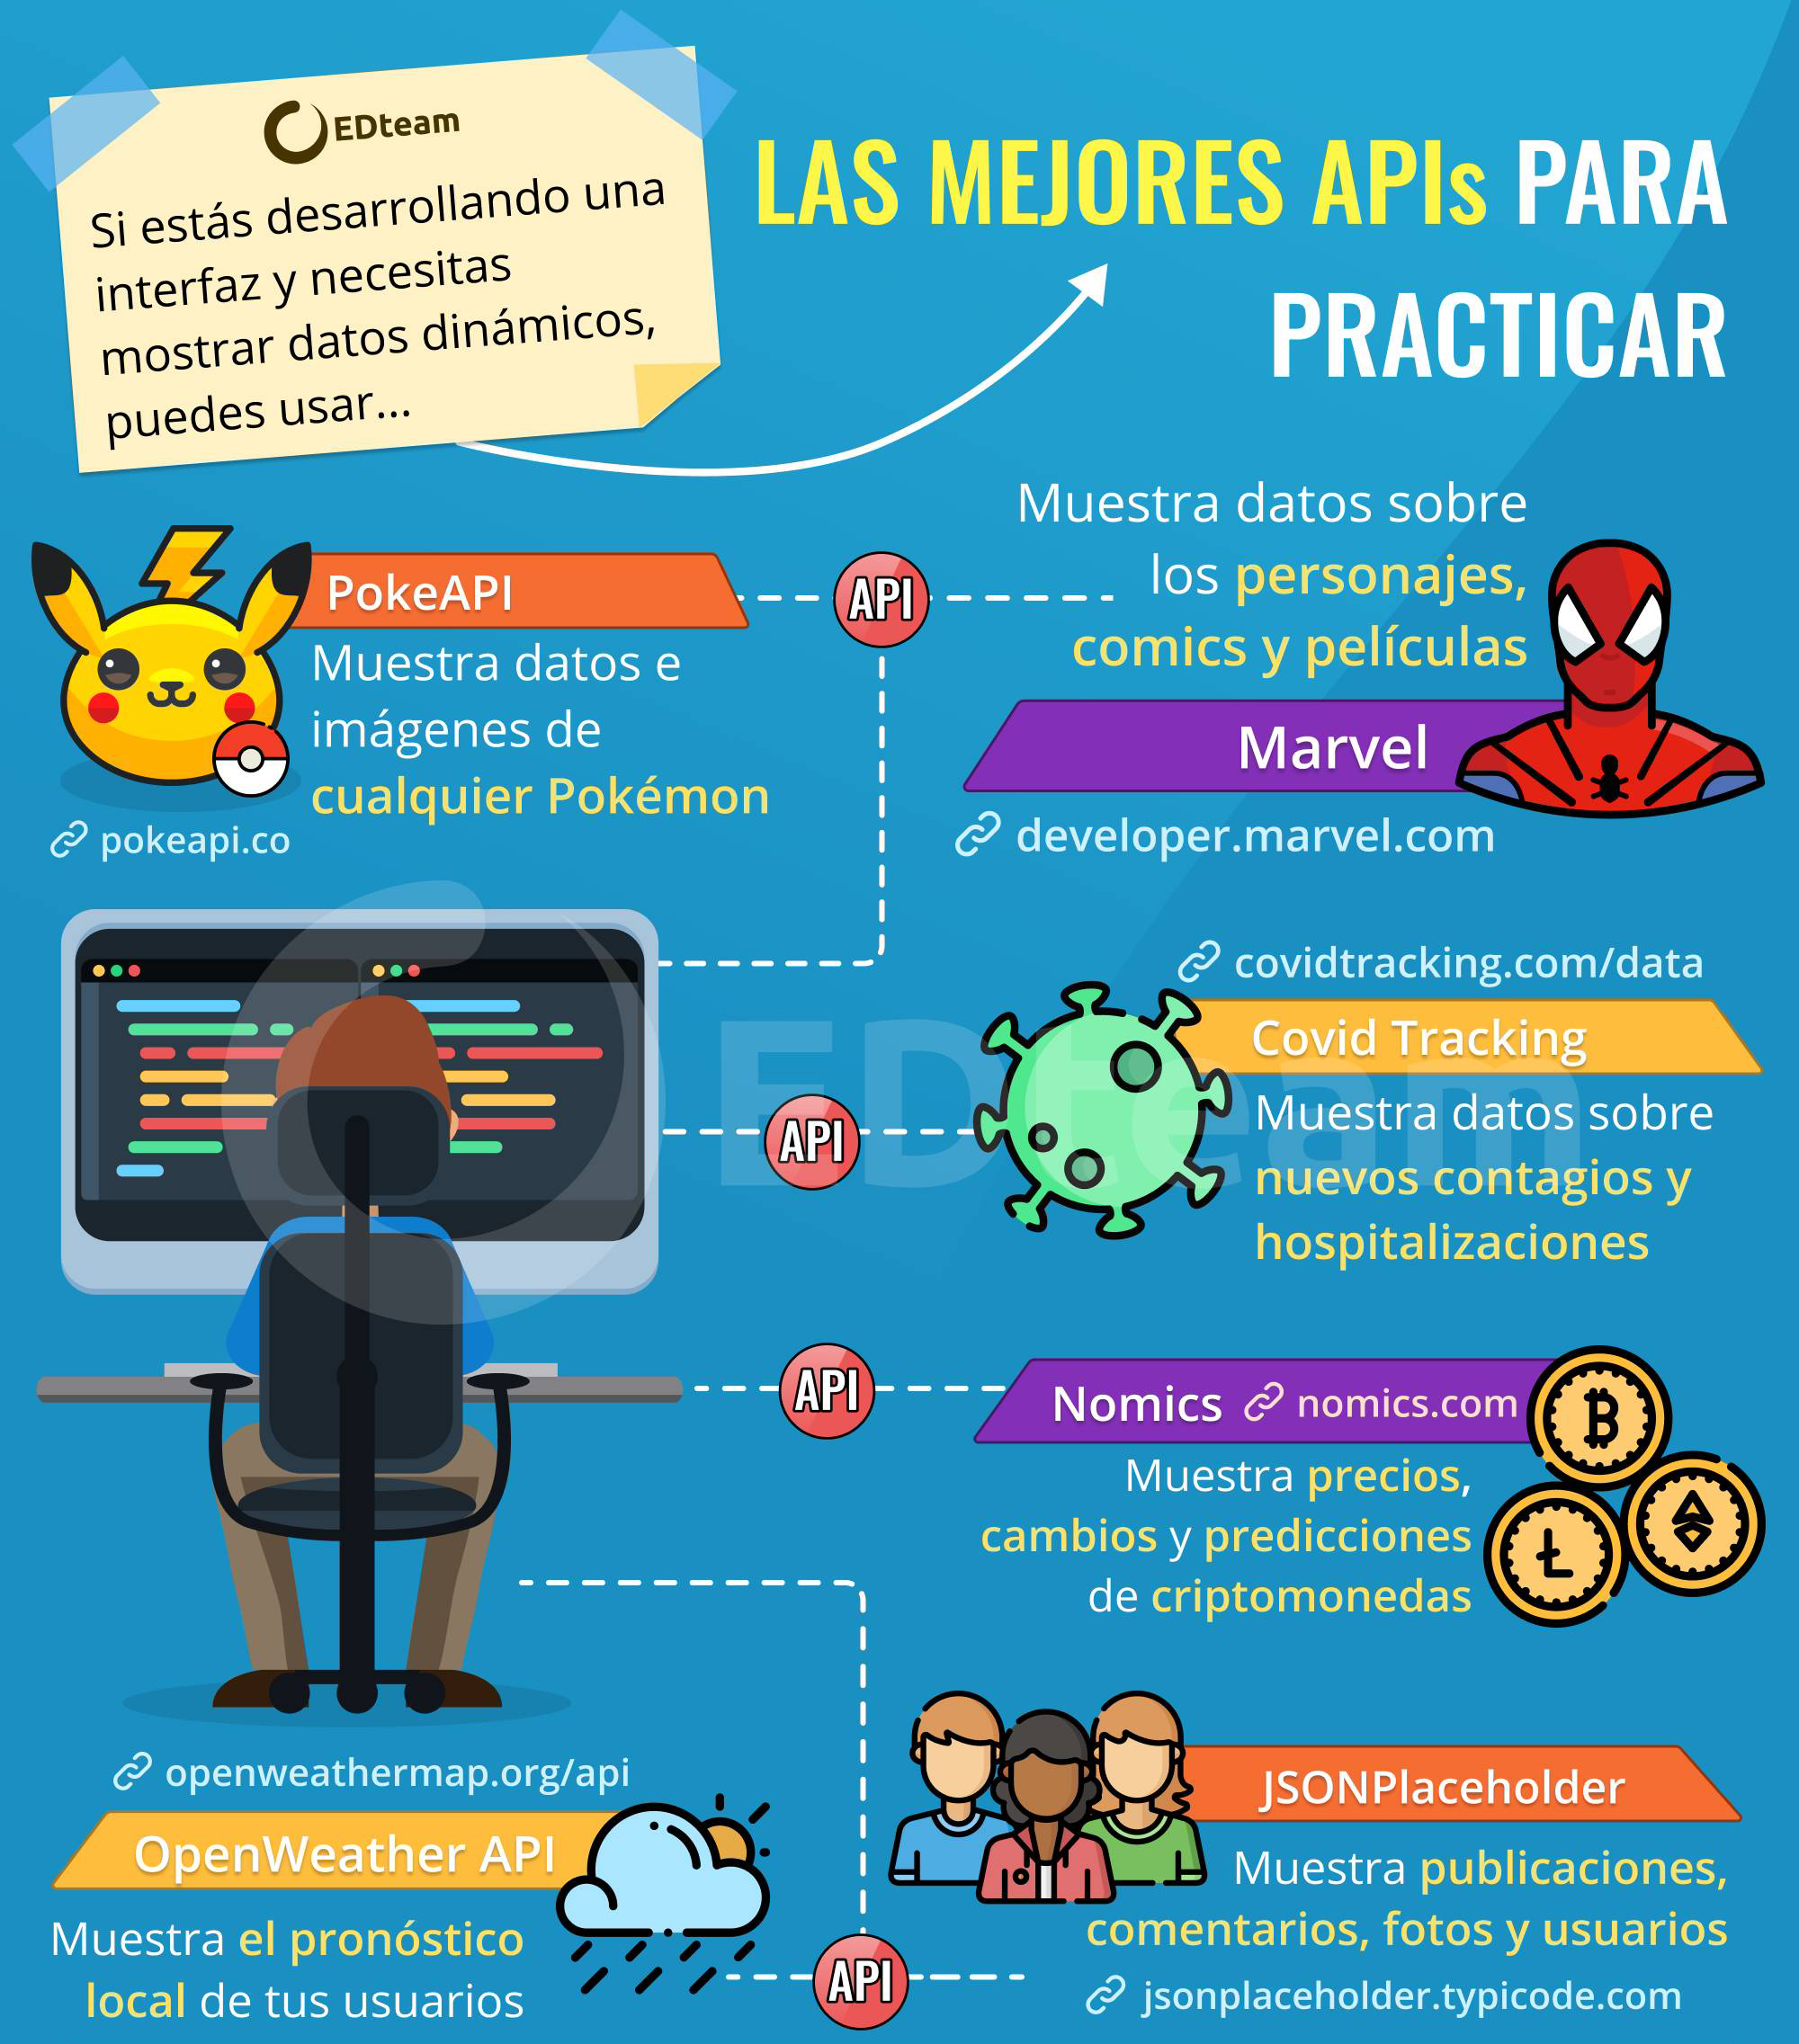

### Instalación

```
pip install requests
```

### JSONPlaceholder

* Es una API de prueba.
* Las operaciones de escritura (POST, PUT, PATCH, DELETE) simulan el éxito pero no modifican los datos permanentemente en el servidor.
* [https://jsonplaceholder.typicode.com/](https://jsonplaceholder.typicode.com/)

### Petición GET

* Envía una solicitud GET a la URL especificada.
* **Sintaxis**: requests.get(url, [params={key: value}], [args])

| Parámetro       | Descripción                                                             | Default |
| --              | --                                                                      | --      |
| url             | Requerida. La url de la solicitud.                                      |         |
| params          | Diccionario o lista de tuplas para enviar como una query string.        | None    |
| allow_redirects | Booleano para habilitar/deshabilitar la redirección.                    | True    |
| auth            | Una tupla para habilitar una determinada autenticación HTTP.            | None    |
| cert            | Un string o tupla que especifica un archivo de certificado o una clave. | None    |
| cookies         | Un diccionario de coolies para enviar a la url especificada.            | None    |
| headers         | Un diccionario de encabezados HTTP para enviar a la url especificada.   | None    |
| proxies         | Un diccionario del protocolo a la URL del proxy.                        | None    |
| stream          | Booleano que indica si la respuesta debe descargarse inmediatamente (False) o transmitirse en tiempo real (True). | False |
| timeout         | Número o una tupla que indica cuántos segundos hay que esperar para que el cliente establezca una conexión o envíe una respuesta. | None (significa que la solicitud continuará hasta que se cierre la conexión) |
| verify          | Boolean que indique si se debe verificar o no el certificado TLS del servidor. | True |

### Listar todas las publicaciones:

In [12]:
import requests
import pandas as pd

response = requests.get("https://jsonplaceholder.typicode.com/posts/")
df = pd.DataFrame(response.json())
df

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...
...,...,...,...,...
95,10,96,quaerat velit veniam amet cupiditate aut numqu...,in non odio excepturi sint eum\nlabore volupta...
96,10,97,quas fugiat ut perspiciatis vero provident,eum non blanditiis soluta porro quibusdam volu...
97,10,98,laboriosam dolor voluptates,doloremque ex facilis sit sint culpa\nsoluta a...
98,10,99,temporibus sit alias delectus eligendi possimu...,quo deleniti praesentium dicta non quod\naut e...


### Obtener una publicación específica (ID 1):

In [10]:
response = requests.get('https://jsonplaceholder.typicode.com/posts/1')
response.json()

{'userId': 1,
 'id': 1,
 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit',
 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}

### Filtrar por usuario (userId=1):

In [20]:
filtro = {'userId': 1}
response = requests.get('https://jsonplaceholder.typicode.com/posts', params=filtro)
df = pd.DataFrame(response.json())
df

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...
5,1,6,dolorem eum magni eos aperiam quia,ut aspernatur corporis harum nihil quis provid...
6,1,7,magnam facilis autem,dolore placeat quibusdam ea quo vitae\nmagni q...
7,1,8,dolorem dolore est ipsam,dignissimos aperiam dolorem qui eum\nfacilis q...
8,1,9,nesciunt iure omnis dolorem tempora et accusan...,consectetur animi nesciunt iure dolore\nenim q...
9,1,10,optio molestias id quia eum,quo et expedita modi cum officia vel magni\ndo...


### Petición POST

* Envía una solicitud POST a la URL especificada.
* **Sintaxis**: requests.post(url, [data={key: value}], [json={key: value}], [args])

| Parámetro       | Descripción                                                                    | Default |
| --              | --                                                                             | --      |
| url             | Requerida. La url de la solicitud.                                             |         |
| data            | Diccionario o lista de tuplas u objeto file para enviar a la url especificada. | None    |
| json            | Objeto JSON para enviar a la url especificada.                                 | None    |
| files           | Diccionario de files para enviar a la url especificada                         | None    |

### Crear una nueva publicación:

In [26]:
new_post = {
    'title': 'Mi Título',
    'body': 'Contenido del post',
    'userId': 1
}
response = requests.post('https://jsonplaceholder.typicode.com/posts', json=new_post)
print(response.status_code) # Debería ser 201 (Created)
print(response.json())      # El servidor devuelve el objeto con un nuevo 'id'

201
{'title': 'Mi Título', 'body': 'Contenido del post', 'userId': 1, 'id': 101}


### Petición PUT

* Reemplazo completo.
* Se debe enviar todo el objeto.

### Modificar completamente una publicación:

In [61]:
updated_data = {
    'id': 1, 
    'title': 'Nuevo Título', 
    'body': 'Cuerpo actualizado', 
    'userId': 1
}
response = requests.put('https://jsonplaceholder.typicode.com/posts/1', json=updated_data)
print(response.status_code) # Debería ser 200 (OK)
print(response.json())      # El servidor devuelve el objeto reemplazado

200
{'id': 1, 'title': 'Nuevo Título', 'body': 'Cuerpo actualizado', 'userId': 1}


### Petición PATCH

* Reemplazo parcial.
* Sólo se envia los campos que se desea cambiar.

### Modificar parcialmente una publicación:

In [64]:
response = requests.patch('https://jsonplaceholder.typicode.com/posts/1', json={'title': 'Título editado'})
print(response.status_code) # Debería ser 200 (OK)
print(response.json())      # El servidor devuelve el objeto reemplazado

200
{'userId': 1, 'id': 1, 'title': 'Título editado', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}


### Petición DELETE

* Envía una solicitud DELETE a la URL especificada.
* Las solicitudes DELETE se realizan para eliminar el recurso especificado (archivo, registro, etc.).
* **Sintaxis**: requests.delete(url, [args])

### Eliminar una publicación:

In [28]:
response = requests.delete('https://jsonplaceholder.typicode.com/posts/1')
print(response.status_code) # Debería ser 200 (OK) o 204 (No Content)

200


### Objeto RESPONSE

| Atributo / Método  | Descripción                                                                      |
| --                 | --                                                                               |
| close()            | Cierra la conexión con el servidor                                               |
| content            | Devuelve el contenido de la respuesta, en bytes. Para el caso de imagen o pdf    |
| cookies            | Devuelve un objeto CookieJar con las cookies enviadas por el servidor            |
| elapsed            | Devuelve un objeto timedelta con el tiempo transcurrido desde el envío de la solicitud hasta la llegada de la respuesta |
| encoding           | Devuelve la codificación usada para decodificar **r.text**                       |
| headers            | Devuelve un diccionario con las cabeceras de la respuesta                        |
| history            | Devuelve una lista de objetos de respuesta con el historial de solicitudes (URL) |
| json()             | Devuelve un objeto JSON del resultado (si el resultado está en formato JSON, de lo contrario lanza un error) |
| links              | Devuelve los enlaces de cabecera                                                 |
| ok                 | Devuelve True si `status_code` es menor que 400, de lo contrario False           |
| raise_for_status() | Si ocurre un error, este método lanza un objeto HTTPError                        |
| reason             | Devuelve un texto correspondiente al código de estado                            |
| request            | Devuelve el objeto de solicitud que originó esta respuesta                       |
| status_code        | Devuelve un número que indica el estado (200 es OK, 404 es Not Found)            |
| text               | Devuelve el contenido de la respuesta en Unicode                                 |
| url                | Devuelve la URL de la respuesta                                                  |

In [29]:
response = requests.get("http://google.com")

In [30]:
response.history

[<Response [301]>]

In [68]:
response.status_code

200

In [69]:
response.url # se observa que la 1ra petición redirige a http://www.google.com

'http://www.google.com/'

In [31]:
response = requests.get("http://google.com", allow_redirects=False) # para que no redireccione

In [32]:
response.history

[]

In [33]:
response.status_code  # 301: moved permanently

301

In [73]:
response.url

'http://google.com/'

In [74]:
response.text

'<HTML><HEAD><meta http-equiv="content-type" content="text/html;charset=utf-8">\n<TITLE>301 Moved</TITLE></HEAD><BODY>\n<H1>301 Moved</H1>\nThe document has moved\n<A HREF="http://www.google.com/">here</A>.\r\n</BODY></HTML>\r\n'

In [75]:
response.encoding

'UTF-8'

In [76]:
response.headers

{'Location': 'http://www.google.com/', 'Content-Type': 'text/html; charset=UTF-8', 'Content-Security-Policy-Report-Only': "object-src 'none';base-uri 'self';script-src 'nonce-Jh_wGSzGzUPEhKFl9vf-aw' 'strict-dynamic' 'report-sample' 'unsafe-eval' 'unsafe-inline' https: http:;report-uri https://csp.withgoogle.com/csp/gws/other-hp", 'Reporting-Endpoints': 'default="//www.google.com/httpservice/retry/jserror?ei=CvHDabXLJ_rJ1sQP1-KZkAo&cad=crash&error=Page%20Crash&jsel=1&bver=2408&dpf=DbSCiYKDZUx1Fp1HwwkEPuKkBY381-x4K8aYwKLEqgQ"', 'Date': 'Wed, 25 Mar 2026 14:28:26 GMT', 'Expires': 'Fri, 24 Apr 2026 14:28:26 GMT', 'Cache-Control': 'public, max-age=2592000', 'Server': 'gws', 'Content-Length': '219', 'X-XSS-Protection': '0', 'X-Frame-Options': 'SAMEORIGIN'}

In [77]:
response.cookies

<RequestsCookieJar[]>

### API Random User Generator

In [37]:
response = requests.get("https://randomuser.me/api/")
response.json()

{'results': [{'gender': 'female',
   'name': {'title': 'Miss', 'first': 'Lívian', 'last': 'Gomes'},
   'location': {'street': {'number': 8472, 'name': 'Rua Bela Vista '},
    'city': 'Ponta Grossa',
    'state': 'Santa Catarina',
    'country': 'Brazil',
    'postcode': 20390,
    'coordinates': {'latitude': '-80.2565', 'longitude': '113.2452'},
    'timezone': {'offset': '+10:00',
     'description': 'Eastern Australia, Guam, Vladivostok'}},
   'email': 'livian.gomes@example.com',
   'login': {'uuid': '971fd1ad-14b1-4d6d-bfc3-f7aafb91c1a8',
    'username': 'brownzebra544',
    'password': 'sherry',
    'salt': 'sSeYz190',
    'md5': '558170c61ede241446337890dd7066d3',
    'sha1': 'd09d67929e2249d7cef76ad91c9367e0fab996c7',
    'sha256': '3fb696ce4094f4b2460ce4d77a8676a143c94dadea0534d040a5caf4ad943f0b'},
   'dob': {'date': '1983-08-13T00:36:55.197Z', 'age': 42},
   'registered': {'date': '2015-01-13T09:55:55.231Z', 'age': 11},
   'phone': '(75) 1716-5800',
   'cell': '(81) 3242-4070',

### API Countries

In [90]:
response = requests.get("https://restcountries.com/v3.1/all?fields=name,capital,currencies")
df = pd.DataFrame(response.json())
df

,name,currencies,capital
0,"{'common': 'Cook Islands', 'official': 'Cook I...","{'CKD': {'name': 'Cook Islands dollar', 'symbo...",[Avarua]
1,"{'common': 'Guinea', 'official': 'Republic of ...","{'GNF': {'name': 'Guinean franc', 'symbol': 'F...",[Conakry]
2,"{'common': 'Christmas Island', 'official': 'Te...","{'AUD': {'name': 'Australian dollar', 'symbol'...",[Flying Fish Cove]
3,"{'common': 'Togo', 'official': 'Togolese Repub...","{'XOF': {'name': 'West African CFA franc', 'sy...",[Lomé]
4,"{'common': 'Taiwan', 'official': 'Republic of ...","{'TWD': {'name': 'New Taiwan dollar', 'symbol'...",[Taipei]
...,...,...,...
245,"{'common': 'DR Congo', 'official': 'Democratic...","{'CDF': {'name': 'Congolese franc', 'symbol': ...",[Kinshasa]
246,"{'common': 'Venezuela', 'official': 'Bolivaria...",{'VES': {'name': 'Venezuelan bolívar soberano'...,[Caracas]
247,"{'common': 'Brunei', 'official': 'Nation of Br...","{'BND': {'name': 'Brunei dollar', 'symbol': '$...",[Bandar Seri Begawan]
248,"{'common': 'Paraguay', 'official': 'Republic o...","{'PYG': {'name': 'Paraguayan guaraní', 'symbol...",[Asunción]


In [38]:
response = requests.get("https://restcountries.com/v3.1/name/brasil")
response.json()

[{'tld': ['.br'],
  'cca2': 'BR',
  'ccn3': '076',
  'cca3': 'BRA',
  'cioc': 'BRA',
  'independent': True,
  'status': 'officially-assigned',
  'unMember': True,
  'idd': {'root': '+5', 'suffixes': ['5']},
  'capital': ['Brasília'],
  'altSpellings': ['BR',
   'Brasil',
   'Federative Republic of Brazil',
   'República Federativa do Brasil'],
  'region': 'Americas',
  'subregion': 'South America',
  'landlocked': False,
  'borders': ['ARG',
   'BOL',
   'COL',
   'GUF',
   'GUY',
   'PRY',
   'PER',
   'SUR',
   'URY',
   'VEN'],
  'area': 8515767.0,
  'maps': {'googleMaps': 'https://goo.gl/maps/waCKk21HeeqFzkNC9',
   'openStreetMaps': 'https://www.openstreetmap.org/relation/59470'},
  'population': 213421037,
  'fifa': 'BRA',
  'car': {'signs': ['BR'], 'side': 'right'},
  'timezones': ['UTC-05:00', 'UTC-04:00', 'UTC-03:00', 'UTC-02:00'],
  'continents': ['South America'],
  'flag': '🇧🇷',
  'name': {'common': 'Brazil',
   'official': 'Federative Republic of Brazil',
   'nativeName': {

### API Dog

In [40]:
response = requests.get("https://dog.ceo/api/breeds/image/random")
response.json()

{'message': 'https://images.dog.ceo/breeds/finnish-lapphund/mochilamvan.jpg',
 'status': 'success'}

### API Fruityvice

In [96]:
response = requests.get("https://www.fruityvice.com/api/fruit/all")
df = pd.DataFrame(response.json())
df.head()

,name,id,family,order,genus,nutritions
0,Persimmon,52,Ebenaceae,Rosales,Diospyros,"{'calories': 81, 'fat': 0.0, 'sugar': 18.0, 'c..."
1,Strawberry,3,Rosaceae,Rosales,Fragaria,"{'calories': 29, 'fat': 0.4, 'sugar': 5.4, 'ca..."
2,Banana,1,Musaceae,Zingiberales,Musa,"{'calories': 96, 'fat': 0.2, 'sugar': 17.2, 'c..."
3,Tomato,5,Solanaceae,Solanales,Solanum,"{'calories': 74, 'fat': 0.2, 'sugar': 2.6, 'ca..."
4,Pear,4,Rosaceae,Rosales,Pyrus,"{'calories': 57, 'fat': 0.1, 'sugar': 10.0, 'c..."


### API Brasil

In [97]:
response = requests.get("https://brasilapi.com.br/api/cptec/v1/cidade")
df = pd.DataFrame(response.json())
df.head()

,nome,id,estado
0,São Benedito,4750,CE
1,São Benedito do Rio Preto,4751,MA
2,São Benedito do Sul,4752,PE
3,São Bento,4753,MA
4,São Bento,4754,PB


In [41]:
cityCode = 999
response = requests.get(f"https://brasilapi.com.br/api/cptec/v1/clima/previsao/{cityCode}")
response.json()

{'cidade': 'Brejo Alegre',
 'estado': 'SP',
 'atualizado_em': '2026-03-27',
 'clima': [{'data': '2026-03-28',
   'condicao': 'pn',
   'condicao_desc': 'Parcialmente Nublado',
   'min': 20,
   'max': 33,
   'indice_uv': 0}]}

In [99]:
ano = 2026
response = requests.get(f"https://brasilapi.com.br/api/feriados/v1/{ano}")
df = pd.DataFrame(response.json())
df

,date,name,type
0,2026-01-01,Confraternização mundial,national
1,2026-02-17,Carnaval,national
2,2026-04-03,Sexta-feira Santa,national
3,2026-04-05,Páscoa,national
4,2026-04-21,Tiradentes,national
5,2026-05-01,Dia do trabalho,national
6,2026-06-04,Corpus Christi,national
7,2026-09-07,Independência do Brasil,national
8,2026-10-12,Nossa Senhora Aparecida,national
9,2026-11-02,Finados,national


## Posibles puntos a ser testeados

* Status code esperado
* Información obtenida en la respuesta sea la esperada
* Estructura de la respuesta sea la esperada
* Tiempo de respuesta
* Reglas de negocio
* Impacto sobre la base de datos
* Etc. 

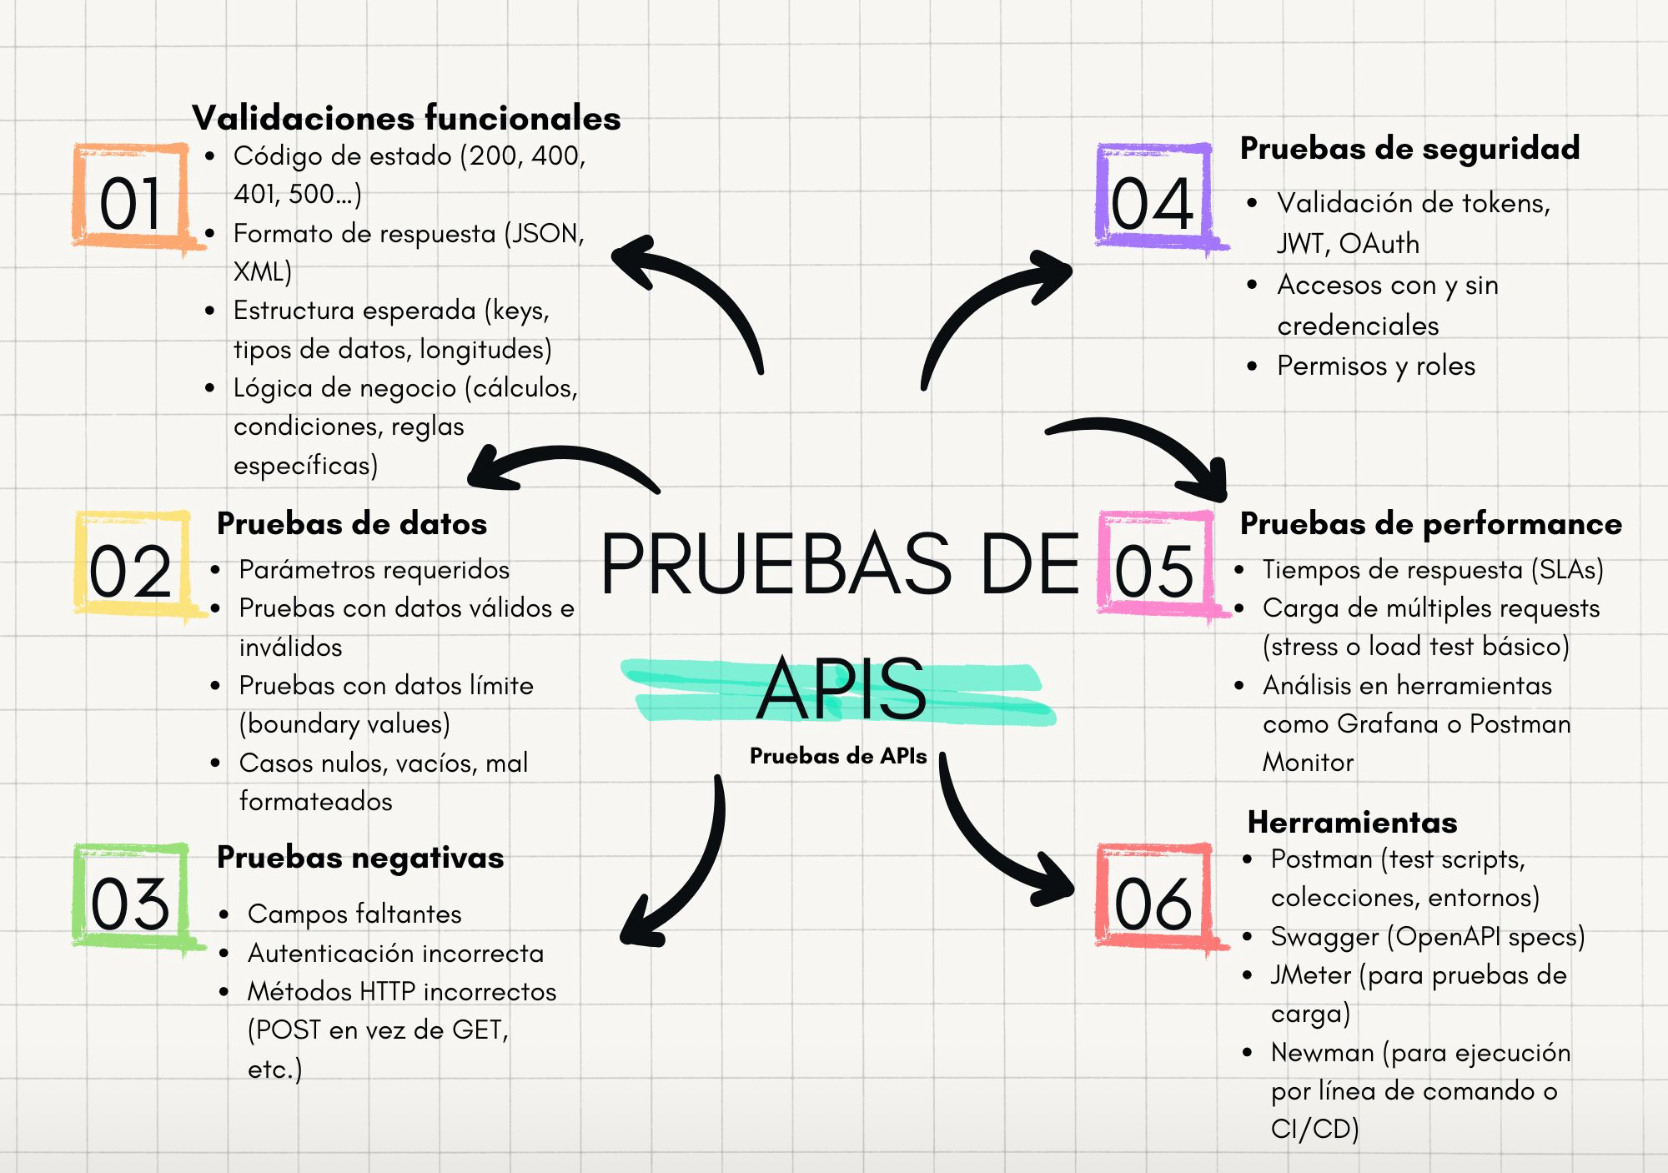

## API Datos Geográficos

* [API del Servicio de Normalización de Datos Geográficos](https://datosgobar.github.io/georef-ar-api/)
* [Libreria requests](https://realpython.com/python-requests/)

In [12]:
%%file api01.py 
import pytest
import requests

def test_geo_ref_ubicacion():
    params = {
    'lat': '-27.2741',
    'lon': '-66.7529'
    }
    response = requests.get('https://apis.datos.gob.ar/georef/api/ubicacion', params=params)
    assert response.status_code == 200
    assert response.json()['ubicacion']['departamento']['nombre'] == 'Belén'

Overwriting api01.py


In [13]:
!pytest api01.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 1 item                                                               

api01.py .                                                               [100%]

============================== 1 passed in 0.25s ===============================
